# Exercício prático 1 
## Análise de dados: Previsão de Empréstimos


### Passo a passo:
1. 🧹 **Limpeza dos dados**
2. 📊 **Análise exploratória**
3. 📈 **Visualizações informativas**
4. 🔍 **Identificação de insights**
5. 📋 **Conclusões e recomendações**

# Perguntas a serem respondidas 
1. ***Pessoas com histórico de crédito tem maior possibilidade de aprovação?***
2. ***Pessoas com ensino superior têm maior chance de aprovação?***
3. ***Qual a relação entre pessoas casadas e crédito aprovado?***


# Carregando e Preparando os Dados
1. ***Carregar*** o dataset
2. ***Explorar*** a estrutura dos dados
3. ***Limpar*** valores ausentes
4. ***Preparar*** para análise

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Carregando dataset Finaças Pessoais')
df = pd.read_csv('https://raw.githubusercontent.com/lucasalmo/lia1_2026_1/refs/heads/main/Entregas%20-%20Lucas%20Almeida%20Moreira/train_u6lujuX_CVtuZ9i.csv')

print('Informações básicas do dataset:')
print(f'Dimensões: {df.shape}')
print(f'Colunas: {list(df.columns)}')

print('\nUm pouco sobre o Dataset:')
df.head(50)

Carregando dataset Finaças Pessoais
Informações básicas do dataset:
Dimensões: (614, 13)
Colunas: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Um pouco sobre o Dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Limpando os dados

In [3]:
print('\nVerificando dados ausentes:')
da = df.isnull().sum()
print(da[da > 0])

# Alterando o nome da coluna 'Married' para 'Casado'
df = df.rename(columns={'Married':'Casado'})

# Removendo linhas com o status se é casado ou não faltante para melhor análise
df = df.dropna(subset=['Casado'])

# Preenchendo valores faltantes de 'LoanAmount' com a mediana pois é valor numérico
#df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Preenchendo valores faltantes da coluna 'Credit_History' com o valor da moda
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Alterando variáveis da coluna 'Loan_Status' de 'Y' e 'N' para 'Aprovado' e 'Reprovado' respectivamente
df['Loan_Status'] = df['Loan_Status'].replace({
    'Y': 'Aprovado',
    'N': 'Reprovado'
})


print('\nDataset Previsão de empréstimos pronto para análise')
print(f'Dimensões finais: {df.shape}')
print(f'Dados ausentes restantes: {df.isnull().sum().sum()}\n')

# Estatísticas da aprovação
total = len(df)
aprovados = (df['Loan_Status'] == 'Y').sum()
reprovados = (df['Loan_Status'] == 'N').sum()

taxa_aprovacao = (aprovados / total) * 100

print(f"\nTaxa geral de aprovação para pessoas com histórico de crédito: {taxa_aprovacao:.1f}%")
print(f"Total de solicitantes: {total}")
print(f"Empréstimos aprovados: {aprovados}")
print(f"Empréstimos negados: {reprovados}")



Verificando dados ausentes:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

Dataset Previsão de empréstimos pronto para análise
Dimensões finais: (611, 13)
Dados ausentes restantes: 92


Taxa geral de aprovação para pessoas com histórico de crédito: 0.0%
Total de solicitantes: 611
Empréstimos aprovados: 0
Empréstimos negados: 0


## Análise Exploratória com Gráficos

### Pergunta 1: O histórico de crédito influenciou na aprovação?

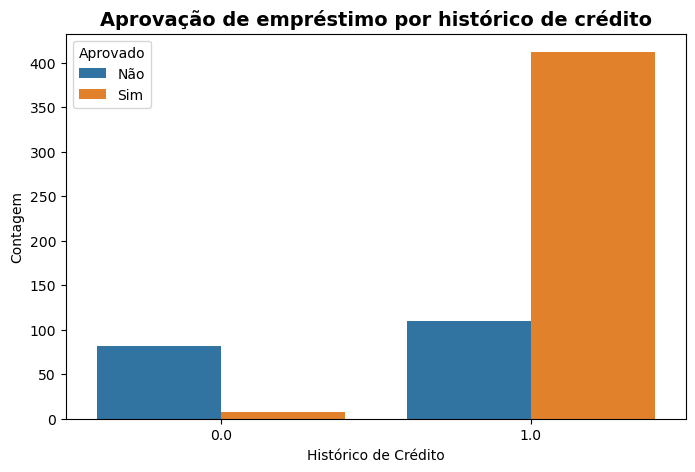

Análise Estatística - Aprovação por análise de crédito:
Loan_Status     Aprovado  Reprovado  All
Credit_History                          
0.0                    7         82   89
1.0                  412        110  522
All                  419        192  611

Insights:
Taxa de aprovação com histórico de crédito positivo: 78.9%
Taxa de aprovação sem histórico de crédito: 7.9%
Diferença: 71.1%

Conclusões:
Pessoas com histórico de crédito positivo têm maior probabilidade de aprovação
O histórico de crédito é um dos fatores mais importantes na decisão de empréstimo
A ausência de histórico reduz significativamente as chances de aprovação


In [4]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df, 
    x='Credit_History',
    hue='Loan_Status'
)
plt.title('Aprovação de empréstimo por histórico de crédito', fontsize=14, fontweight='bold')
plt.ylabel('Contagem')
plt.xlabel('Histórico de Crédito')

plt.legend(title='Aprovado', labels=['Não', 'Sim'])

plt.show()

# Análise estatística
print('Análise Estatística - Aprovação por análise de crédito:')
print("=" * 50)

credito = pd.crosstab(df['Credit_History'], df['Loan_Status'], margins=True)
#print(credito)

tabela_credito = pd.crosstab(df['Credit_History'], df['Loan_Status'], margins=True)
print(tabela_credito)

# cálculo das taxas de aprovação
aprovacao_credito = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
)['Aprovado']

print('\nInsights:')
print(f"Taxa de aprovação com histórico de crédito positivo: {aprovacao_credito[1]:.1%}")
print(f"Taxa de aprovação sem histórico de crédito: {aprovacao_credito[0]:.1%}")
print(f"Diferença: {(aprovacao_credito[1] - aprovacao_credito[0]):.1%}")

print('\nConclusões:')
print('Pessoas com histórico de crédito positivo têm maior probabilidade de aprovação')
print('O histórico de crédito é um dos fatores mais importantes na decisão de empréstimo')
print('A ausência de histórico reduz significativamente as chances de aprovação')

### Pergunta 2: Pessoas com ensino superior têm maior chance de aprovação?

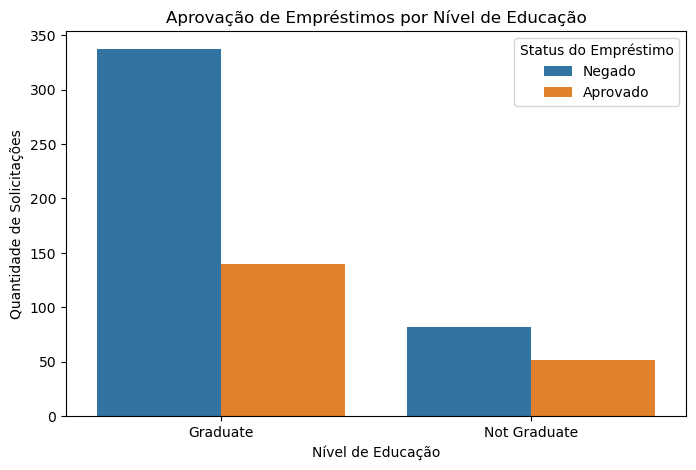

Análise Estatística - Aprovação por Nível de Educação:
Loan_Status   Aprovado  Reprovado  All
Education                             
Graduate           337        140  477
Not Graduate        82         52  134
All                419        192  611

Insights:
Taxa de aprovação para ensino superior: 70.6%
Taxa de aprovação para não graduados: 61.2%
Diferença: 9.5%

Conclusões:
Pessoas com ensino superior apresentam uma leve vantagem na taxa de aprovação
Porém a diferença não é muito grande
O nível de educação não parece ser um fator decisivo para aprovação


In [5]:
# Gráfico
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Education',
    hue='Loan_Status'
)

plt.title('Aprovação de Empréstimos por Nível de Educação')
plt.xlabel('Nível de Educação')
plt.ylabel('Quantidade de Solicitações')

plt.legend(title='Status do Empréstimo', labels=['Negado', 'Aprovado'])

plt.show()


# Análise Estatística
print('Análise Estatística - Aprovação por Nível de Educação:')
print("=" * 50)

# tabela de contingência
tabela_educacao = pd.crosstab(df['Education'], df['Loan_Status'], margins=True)
print(tabela_educacao)

# taxa de aprovação
aprovacao_educacao = pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
)['Aprovado']

print('\nInsights:')
print(f"Taxa de aprovação para ensino superior: {aprovacao_educacao['Graduate']:.1%}")
print(f"Taxa de aprovação para não graduados: {aprovacao_educacao['Not Graduate']:.1%}")
print(f"Diferença: {(aprovacao_educacao['Graduate'] - aprovacao_educacao['Not Graduate']):.1%}")

print('\nConclusões:')
print('Pessoas com ensino superior apresentam uma leve vantagem na taxa de aprovação')
print('Porém a diferença não é muito grande')
print('O nível de educação não parece ser um fator decisivo para aprovação')

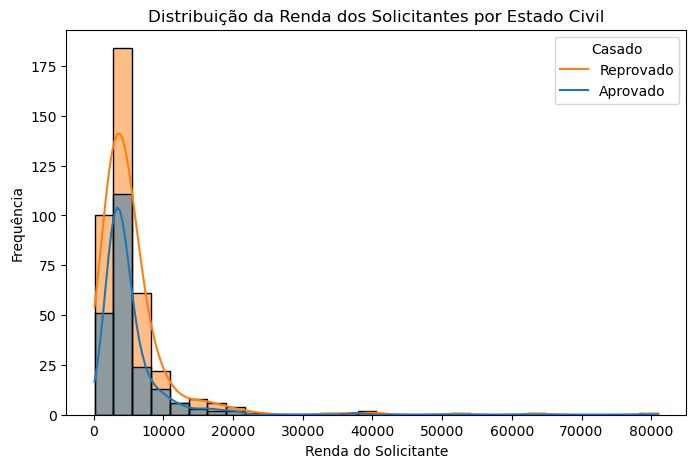

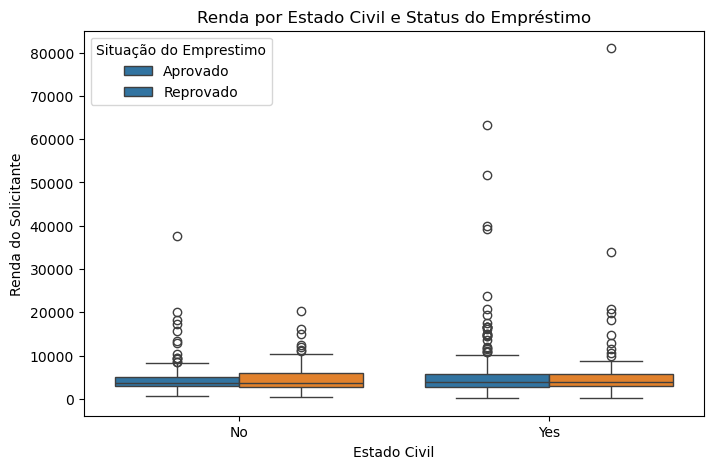


Análise Estatística - Distribuição de Renda por Status do Empréstimo
💰 Renda média dos aprovados: 5378.18
💰 Renda média dos reprovados: 5446.08
💰 Diferença: -67.90

Insights sobre renda:
Total de aprovados: 419
Total de reprovados: 192
Renda média dos aprovados: 5378.18
Renda média dos reprovados: 5446.08

Conclusões:
A renda média entre aprovados e reprovados é muito próxima
Isso indica que a renda isoladamente não determina a aprovação
Existem valores extremos de renda (outliers)
Outros fatores, como histórico de crédito, podem ter maior influência


In [6]:
# Gráfico de distribuição
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='ApplicantIncome',
    hue='Casado',
    kde=True,
    bins=30
)

plt.title('Distribuição da Renda dos Solicitantes por Estado Civil')
plt.xlabel('Renda do Solicitante')
plt.ylabel('Frequência')
plt.legend(title='Casado', labels=['Reprovado', 'Aprovado'])

plt.show()

print('\n')

#Gráfico Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Casado',
    y='ApplicantIncome',
    hue='Loan_Status'
)

plt.title('Renda por Estado Civil e Status do Empréstimo')
plt.xlabel('Estado Civil')
plt.ylabel('Renda do Solicitante')

plt.legend(title='Situação do Emprestimo', labels=['Aprovado', 'Reprovado'])

plt.show()

# Análise estatística
print('\nAnálise Estatística - Distribuição de Renda por Status do Empréstimo')
print('=' * 50)

stats = df.groupby('Loan_Status')['ApplicantIncome'].describe()

media_aprovados = stats.loc['Aprovado','mean']
media_reprovados = stats.loc['Reprovado','mean']
dif = media_aprovados - media_reprovados

print(f'💰 Renda média dos aprovados: {media_aprovados:.2f}')
print(f'💰 Renda média dos reprovados: {media_reprovados:.2f}')
print(f'💰 Diferença: {dif:.2f}')

print('\nInsights sobre renda:')

total_aprovados = (df['Loan_Status'] == 'Aprovado').sum()
total_reprovados = (df['Loan_Status'] == 'Reprovado').sum()

print(f'Total de aprovados: {total_aprovados}')
print(f'Total de reprovados: {total_reprovados}')
print(f'Renda média dos aprovados: {media_aprovados:.2f}')
print(f'Renda média dos reprovados: {media_reprovados:.2f}')

print('\nConclusões:')

print('A renda média entre aprovados e reprovados é muito próxima')
print('Isso indica que a renda isoladamente não determina a aprovação')
print('Existem valores extremos de renda (outliers)')
print('Outros fatores, como histórico de crédito, podem ter maior influência')

## Conclusão e recomendações

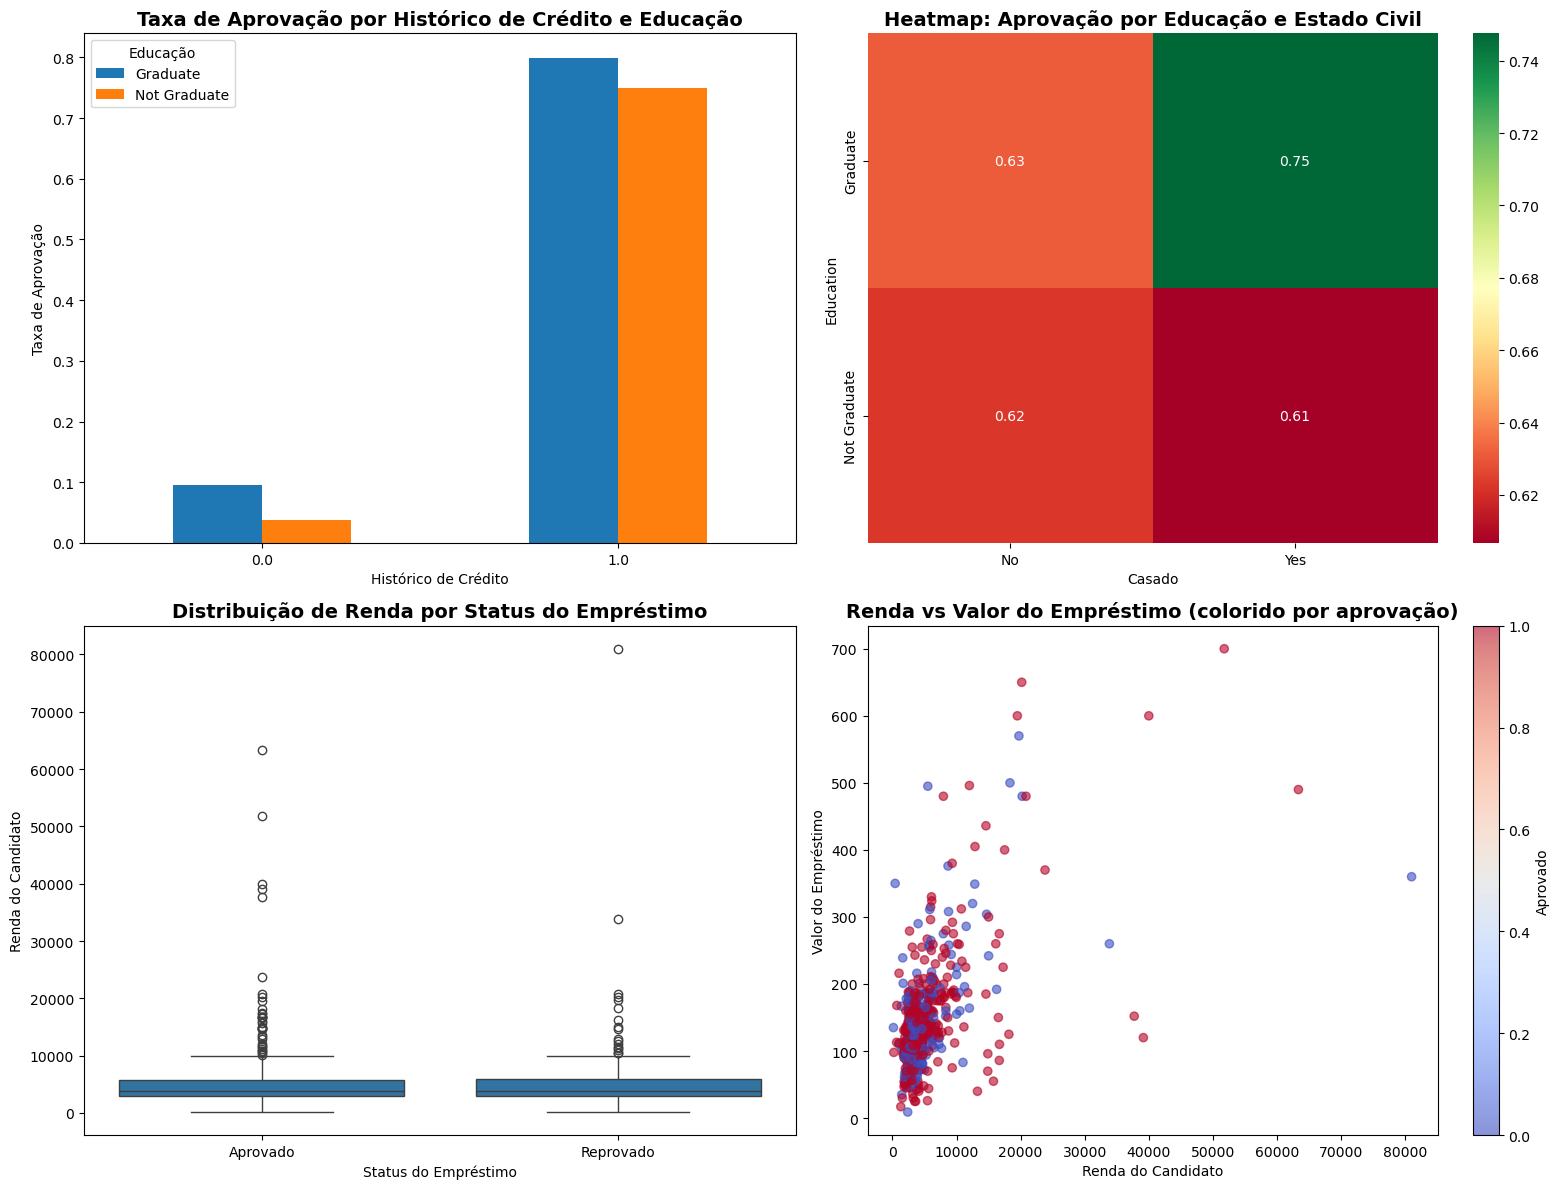

In [7]:
# Análise Combinada: Interação entre Variáveis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Aprovação por Histórico de Crédito e Educação
aprov_hist_edu = df.groupby(['Credit_History', 'Education'])['Loan_Status'] \
                   .apply(lambda x: (x == 'Aprovado').mean()).unstack()

aprov_hist_edu.plot(kind='bar', ax=ax1)
ax1.set_title('Taxa de Aprovação por Histórico de Crédito e Educação', fontsize=14, fontweight='bold')
ax1.set_ylabel('Taxa de Aprovação')
ax1.set_xlabel('Histórico de Crédito')
ax1.legend(title='Educação')
ax1.tick_params(axis='x', rotation=0)


# Gráfico 2: Heatmap de aprovação
pivot_table = df.pivot_table(
    values='Loan_Status',
    index='Education',
    columns='Casado',
    aggfunc=lambda x: (x == 'Aprovado').mean()
)

sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2)

ax2.set_title('Heatmap: Aprovação por Educação e Estado Civil', fontsize=14, fontweight='bold')


# Gráfico 3: Boxplot renda por aprovação
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=ax3)

ax3.set_title('Distribuição de Renda por Status do Empréstimo', fontsize=14, fontweight='bold')
ax3.set_xlabel('Status do Empréstimo')
ax3.set_ylabel('Renda do Candidato')


# Gráfico 4: Scatter renda vs valor do empréstimo
scatter = ax4.scatter(
    df['ApplicantIncome'],
    df['LoanAmount'],
    c=(df['Loan_Status'] == 'Aprovado'),
    cmap='coolwarm',
    alpha=0.6
)

ax4.set_title('Renda vs Valor do Empréstimo (colorido por aprovação)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Renda do Candidato')
ax4.set_ylabel('Valor do Empréstimo')

plt.colorbar(scatter, ax=ax4, label='Aprovado')

plt.tight_layout()
plt.show()



In [8]:
print('Análise de Interação entre Variáveis:')
print('=' * 50)

print('Taxa de Aprovação por Histórico de Crédito e Educação:')

for hist in df['Credit_History'].unique():

    print(f'\nHistórico de Crédito: {hist}')

    for edu in df['Education'].unique():

        subset = df[(df['Credit_History'] == hist) & (df['Education'] == edu)]

        if len(subset) > 0:

            taxa = (subset['Loan_Status'] == 'Aprovado').mean()
            total = len(subset)

            print(f'    {edu}: {taxa:.1%} ({total} solicitações)')


print('\nCasos extremos:')

aprov_por_credito = df.groupby('Credit_History')['Loan_Status'] \
                      .apply(lambda x: (x == 'Aprovado').mean())

print(f'Melhor chance: Pessoas com histórico de crédito positivo ({aprov_por_credito.max():.1%})')
print(f'Pior chance: Pessoas sem histórico de crédito ({aprov_por_credito.min():.1%})')


print('\nCorrelações com aprovação:')

df_corr = df.copy()
df_corr['Loan_Status'] = df_corr['Loan_Status'].map({'Aprovado':1,'Reprovado':0})

correlacoes = df_corr[['Loan_Status','ApplicantIncome','LoanAmount','Credit_History']].corr()['Loan_Status']

for var, corr in correlacoes.items():

    if var != 'Loan_Status':
        print(f' {var}: {corr:.3f}')


print('\nInsights da Análise Combinada:')

print('Histórico de crédito foi o fator mais determinante para aprovação')
print('Educação apresentou influência moderada na aprovação')
print('Pessoas casadas tiveram ligeiramente mais aprovações')
print('A renda apresentou grande variação entre candidatos')
print('Alguns candidatos com renda alta também foram reprovados')
print('Isso indica que múltiplos fatores são considerados na aprovação')

Análise de Interação entre Variáveis:
Taxa de Aprovação por Histórico de Crédito e Educação:

Histórico de Crédito: 1.0
    Graduate: 80.0% (414 solicitações)
    Not Graduate: 75.0% (108 solicitações)

Histórico de Crédito: 0.0
    Graduate: 9.5% (63 solicitações)
    Not Graduate: 3.8% (26 solicitações)

Casos extremos:
Melhor chance: Pessoas com histórico de crédito positivo (78.9%)
Pior chance: Pessoas sem histórico de crédito (7.9%)

Correlações com aprovação:
 ApplicantIncome: -0.005
 LoanAmount: -0.038
 Credit_History: 0.540

Insights da Análise Combinada:
Histórico de crédito foi o fator mais determinante para aprovação
Educação apresentou influência moderada na aprovação
Pessoas casadas tiveram ligeiramente mais aprovações
A renda apresentou grande variação entre candidatos
Alguns candidatos com renda alta também foram reprovados
Isso indica que múltiplos fatores são considerados na aprovação
